# 🦠 Project 2: Covid-19 Data Analysis Project using Python

**Objective:** Collect and analyze real-time data on Covid-19 cases, recoveries, and fatalities from various sources. Identify patterns, trends, and correlations — including the impact of vaccination rates and lockdown measures.

**Skills Covered:**
- Real-time data collection via public APIs & CSV sources
- Data manipulation & cleaning with Pandas & NumPy
- Data visualization with Matplotlib & Seaborn
- Trend analysis, correlation, and pattern identification

**Libraries Used:** pandas, numpy, matplotlib, seaborn, requests, plotly

## Step 1: Install & Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn plotly --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2: Load Covid-19 Data
> Using Our World in Data (OWID) — the most comprehensive and up-to-date public COVID-19 dataset

In [3]:
# Load OWID Covid-19 dataset (comprehensive global dataset)
url = 'https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv'
print('⬇️  Downloading data from Our World in Data...')
df_raw = pd.read_csv(url)
print(f'✅ Data loaded! Shape: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}): {list(df_raw.columns[:20])}...')
df_raw.head(3)

⬇️  Downloading data from Our World in Data...
✅ Data loaded! Shape: (429435, 67)
Columns (67): ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients']...


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [4]:
# Basic info
print(f'Date Range  : {df_raw["date"].min()} to {df_raw["date"].max()}')
print(f'Countries   : {df_raw["location"].nunique()}')
print(f'Total Rows  : {len(df_raw):,}')

Date Range  : 2020-01-01 to 2024-08-14
Countries   : 255
Total Rows  : 429,435


## Step 3: Data Cleaning & Preparation

In [5]:
# Select key columns
key_cols = [
    'iso_code', 'continent', 'location', 'date',
    'total_cases', 'new_cases', 'total_deaths', 'new_deaths',
    'total_cases_per_million', 'new_cases_smoothed',
    'total_deaths_per_million', 'new_deaths_smoothed',
    'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated',
    'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred',
    'reproduction_rate', 'stringency_index',
    'population', 'population_density',
    'median_age', 'aged_65_older', 'gdp_per_capita',
    'hospital_beds_per_thousand', 'human_development_index'
]

# Keep only available columns
available_cols = [c for c in key_cols if c in df_raw.columns]
df = df_raw[available_cols].copy()
df['date'] = pd.to_datetime(df['date'])

# Remove continent-level aggregates (keep only countries)
df = df[df['continent'].notna()].reset_index(drop=True)

print(f'Cleaned dataset shape: {df.shape}')
print(f'Countries: {df["location"].nunique()}')
df.head()

Cleaned dataset shape: (402910, 26)
Countries: 243


,iso_code,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,total_cases_per_million,new_cases_smoothed,...,people_fully_vaccinated_per_hundred,reproduction_rate,stringency_index,population,population_density,median_age,aged_65_older,gdp_per_capita,hospital_beds_per_thousand,human_development_index
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,0.0,41128772,54.42,18.6,2.58,1803.99,0.5,0.51
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,0.0,41128772,54.42,18.6,2.58,1803.99,0.5,0.51
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,0.0,41128772,54.42,18.6,2.58,1803.99,0.5,0.51
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,0.0,41128772,54.42,18.6,2.58,1803.99,0.5,0.51
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,0.0,41128772,54.42,18.6,2.58,1803.99,0.5,0.51


In [6]:
# Missing values overview
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print('Missing Values (%):')
print(missing_pct.round(1))

Missing Values (%):
people_fully_vaccinated                84.4
people_fully_vaccinated_per_hundred    84.4
people_vaccinated_per_hundred          83.7
people_vaccinated                      83.7
total_vaccinations                     82.6
reproduction_rate                      54.4
stringency_index                       51.3
hospital_beds_per_thousand             28.3
human_development_index                21.2
aged_65_older                          20.2
gdp_per_capita                         18.9
median_age                             17.4
population_density                     10.9
new_cases_smoothed                      3.5
new_deaths_smoothed                     3.4
new_cases                               3.2
new_deaths                              3.1
total_cases_per_million                 2.8
total_cases                             2.8
total_deaths                            2.8
total_deaths_per_million                2.8
dtype: float64


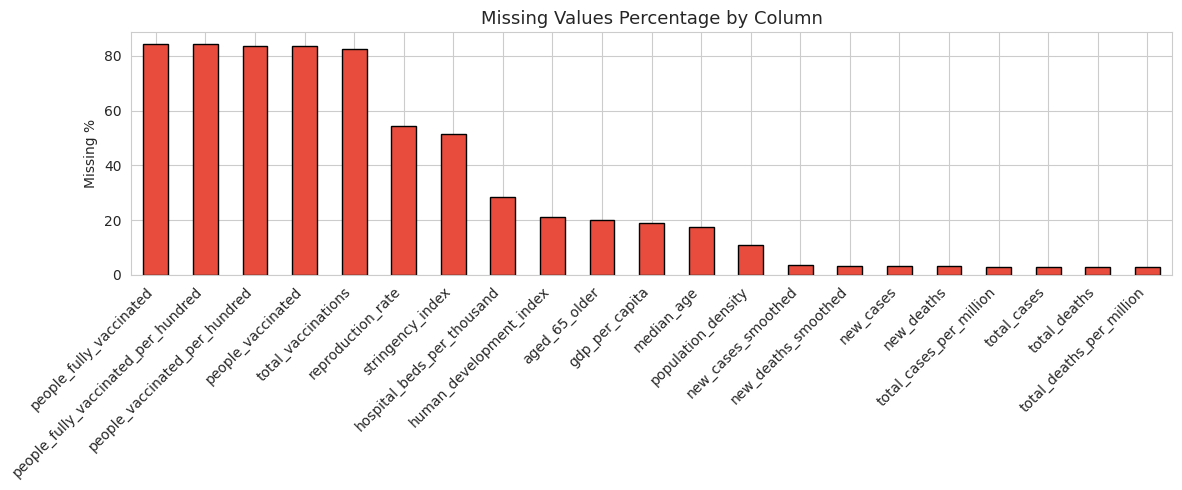

In [7]:
# Visualize missing data
plt.figure(figsize=(12, 5))
missing_pct.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Missing Values Percentage by Column', fontsize=13)
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 4: Global Covid-19 Overview

In [8]:
# Get the latest data per country
latest = df.sort_values('date').groupby('location').last().reset_index()

total_cases  = latest['total_cases'].sum()
total_deaths = latest['total_deaths'].sum()
total_vacc   = latest['people_fully_vaccinated'].sum()
cfr          = (total_deaths / total_cases) * 100

print('=' * 50)
print('     GLOBAL COVID-19 SUMMARY (Latest Data)')
print('=' * 50)
print(f'  Total Confirmed Cases  : {total_cases:,.0f}')
print(f'  Total Deaths           : {total_deaths:,.0f}')
print(f'  Total Fully Vaccinated : {total_vacc:,.0f}')
print(f'  Global Case Fatality % : {cfr:.2f}%')
print(f'  Countries/Territories  : {latest["location"].nunique()}')

     GLOBAL COVID-19 SUMMARY (Latest Data)
  Total Confirmed Cases  : 775,866,783
  Total Deaths           : 7,057,132
  Total Fully Vaccinated : 5,229,018,079
  Global Case Fatality % : 0.91%
  Countries/Territories  : 243


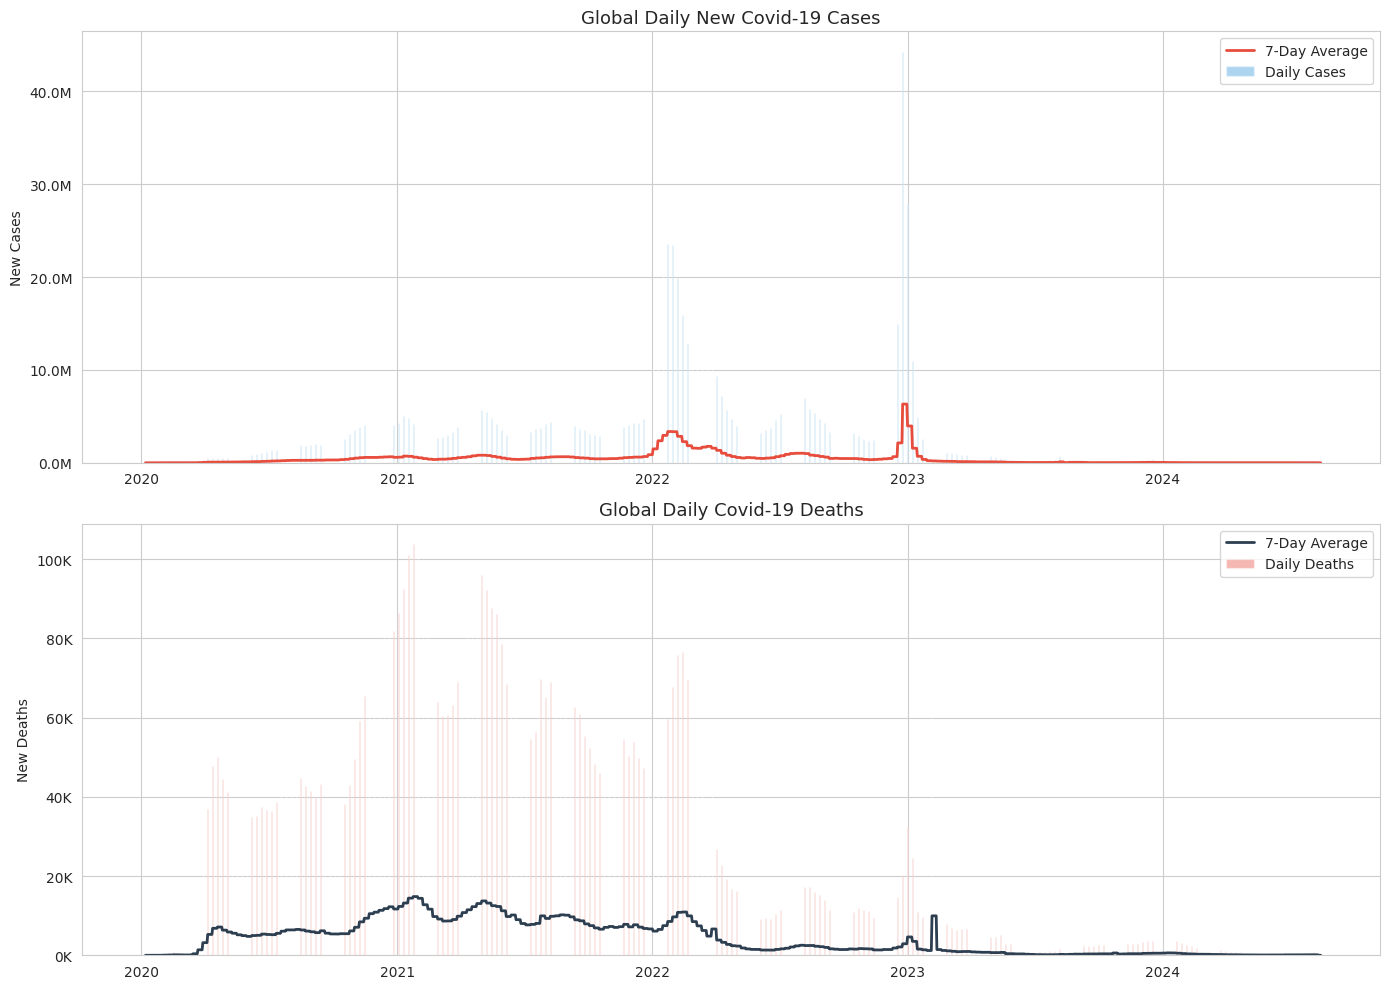

In [9]:
# Global daily cases over time
global_daily = df.groupby('date')[['new_cases', 'new_deaths']].sum().reset_index()
global_daily['new_cases_7day']  = global_daily['new_cases'].rolling(7).mean()
global_daily['new_deaths_7day'] = global_daily['new_deaths'].rolling(7).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily Cases
axes[0].bar(global_daily['date'], global_daily['new_cases'], color='#3498db', alpha=0.4, label='Daily Cases')
axes[0].plot(global_daily['date'], global_daily['new_cases_7day'], color='#e74c3c', lw=2, label='7-Day Average')
axes[0].set_title('Global Daily New Covid-19 Cases', fontsize=13)
axes[0].set_ylabel('New Cases')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Daily Deaths
axes[1].bar(global_daily['date'], global_daily['new_deaths'], color='#e74c3c', alpha=0.4, label='Daily Deaths')
axes[1].plot(global_daily['date'], global_daily['new_deaths_7day'], color='#2c3e50', lw=2, label='7-Day Average')
axes[1].set_title('Global Daily Covid-19 Deaths', fontsize=13)
axes[1].set_ylabel('New Deaths')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

## Step 5: Top Countries Analysis

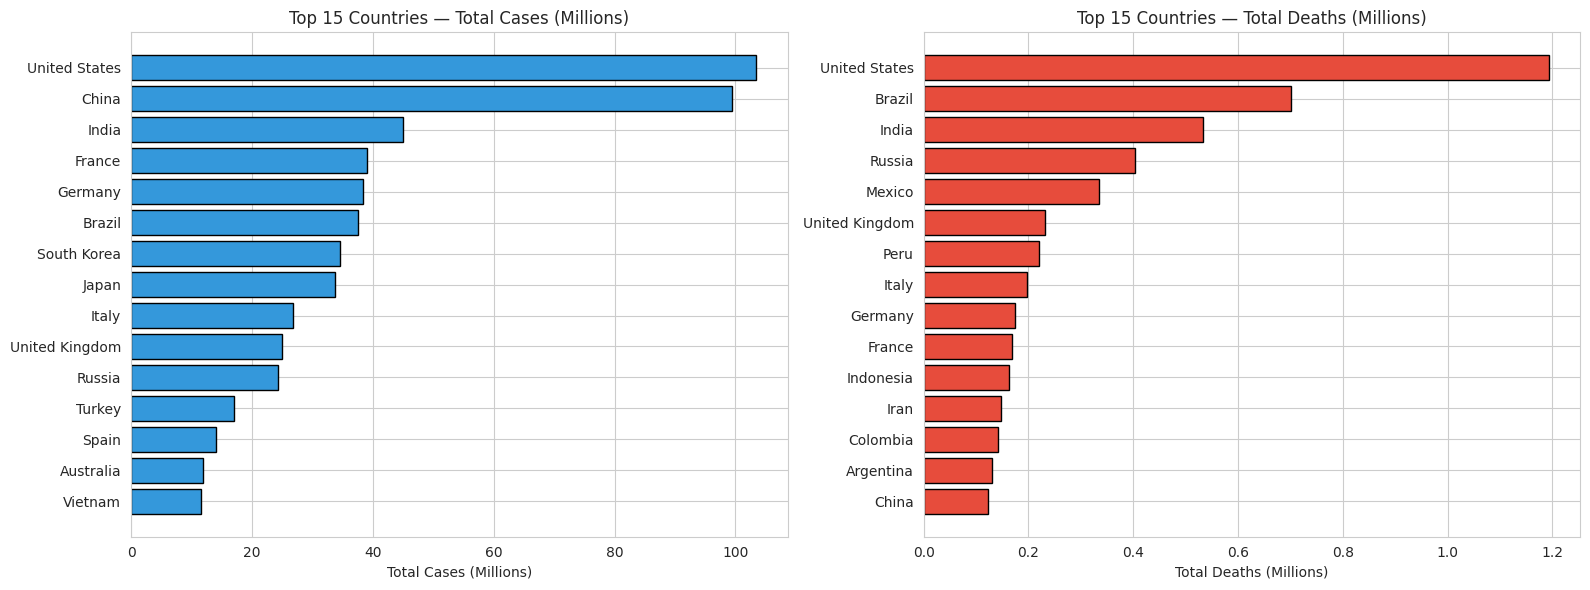

In [10]:
# Top 15 countries by total cases
top15_cases  = latest.nlargest(15, 'total_cases')[['location', 'total_cases', 'total_deaths']].dropna()
top15_deaths = latest.nlargest(15, 'total_deaths')[['location', 'total_cases', 'total_deaths']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top by cases
bars = axes[0].barh(top15_cases['location'], top15_cases['total_cases']/1e6,
                    color='#3498db', edgecolor='black')
axes[0].set_title('Top 15 Countries — Total Cases (Millions)', fontsize=12)
axes[0].set_xlabel('Total Cases (Millions)')
axes[0].invert_yaxis()

# Top by deaths
axes[1].barh(top15_deaths['location'], top15_deaths['total_deaths']/1e6,
             color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 15 Countries — Total Deaths (Millions)', fontsize=12)
axes[1].set_xlabel('Total Deaths (Millions)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

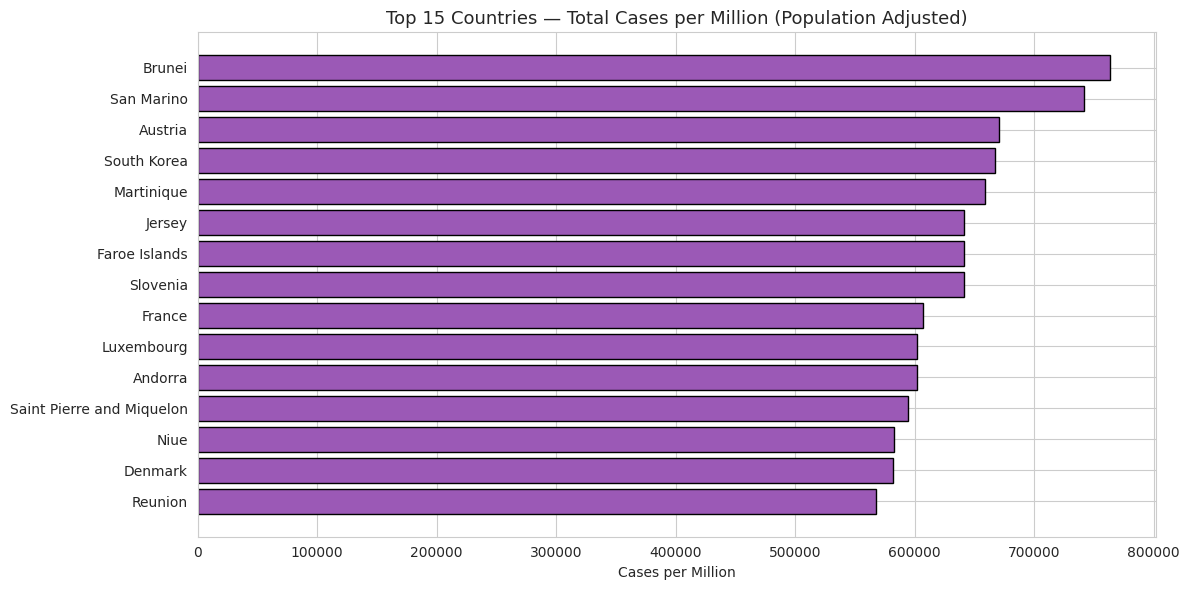

In [11]:
# Top 15 countries by cases per million (population-adjusted)
top15_per_million = latest.dropna(subset=['total_cases_per_million']).nlargest(15, 'total_cases_per_million')

plt.figure(figsize=(12, 6))
plt.barh(top15_per_million['location'], top15_per_million['total_cases_per_million'],
         color='#9b59b6', edgecolor='black')
plt.title('Top 15 Countries — Total Cases per Million (Population Adjusted)', fontsize=13)
plt.xlabel('Cases per Million')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 6: Country-Level Trend Analysis

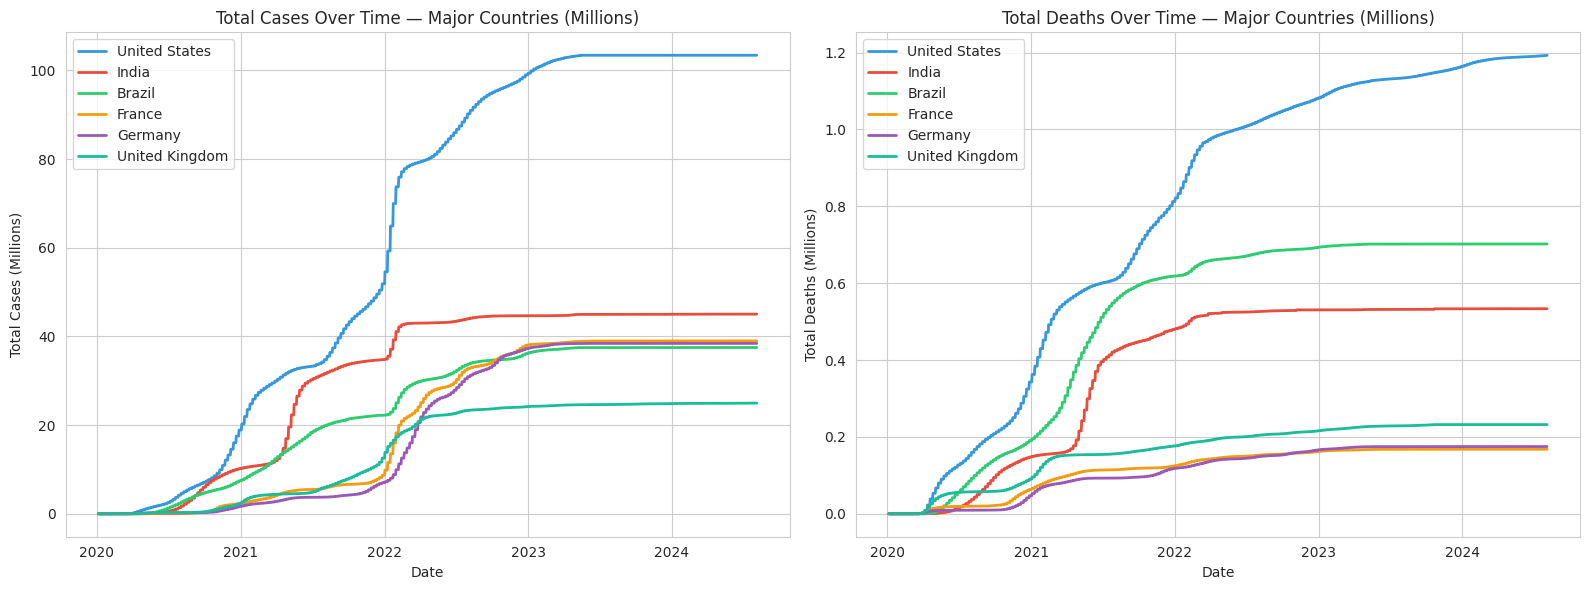

In [12]:
# Compare major countries over time
countries_to_compare = ['United States', 'India', 'Brazil', 'France', 'Germany', 'United Kingdom']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for country, color in zip(countries_to_compare, colors):
    country_df = df[df['location'] == country].sort_values('date')
    if not country_df.empty:
        axes[0].plot(country_df['date'], country_df['total_cases']/1e6,
                     label=country, color=color, lw=2)
        axes[1].plot(country_df['date'], country_df['total_deaths']/1e6,
                     label=country, color=color, lw=2)

axes[0].set_title('Total Cases Over Time — Major Countries (Millions)', fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Cases (Millions)')
axes[0].legend()

axes[1].set_title('Total Deaths Over Time — Major Countries (Millions)', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Deaths (Millions)')
axes[1].legend()

plt.tight_layout()
plt.show()

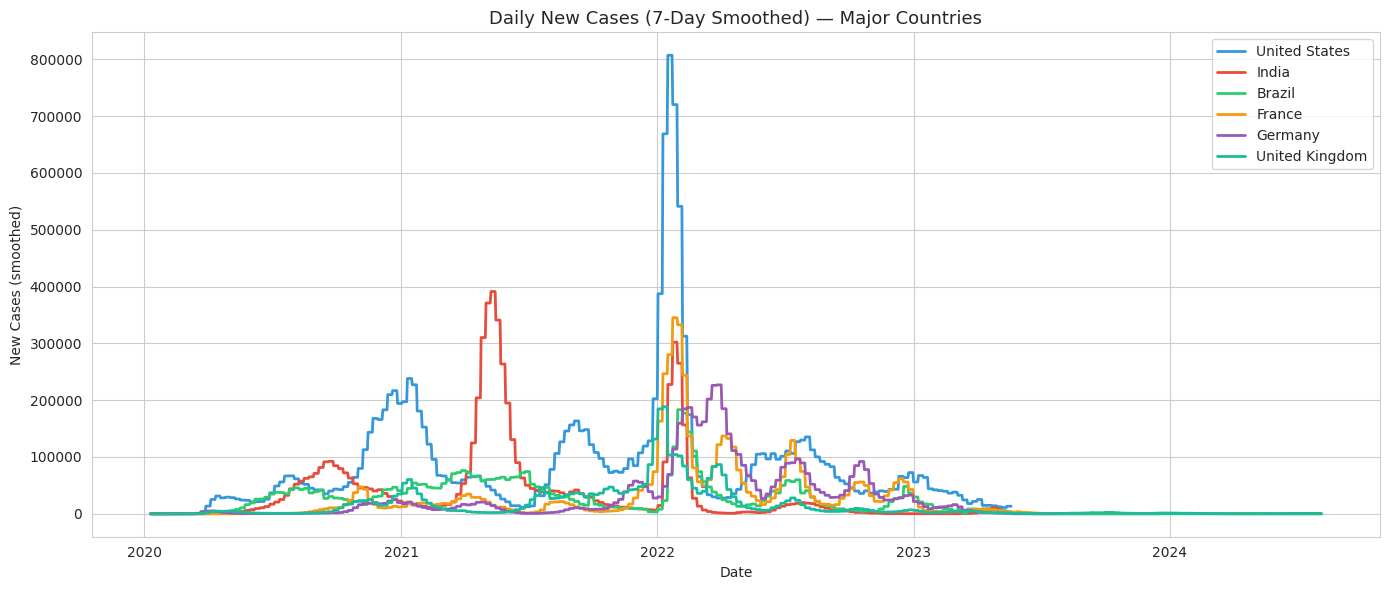

In [13]:
# Daily new cases smoothed — major countries
plt.figure(figsize=(14, 6))
for country, color in zip(countries_to_compare, colors):
    country_df = df[df['location'] == country].sort_values('date')
    if 'new_cases_smoothed' in country_df.columns:
        plt.plot(country_df['date'], country_df['new_cases_smoothed'],
                 label=country, color=color, lw=2)

plt.title('Daily New Cases (7-Day Smoothed) — Major Countries', fontsize=13)
plt.xlabel('Date')
plt.ylabel('New Cases (smoothed)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 7: Vaccination Analysis

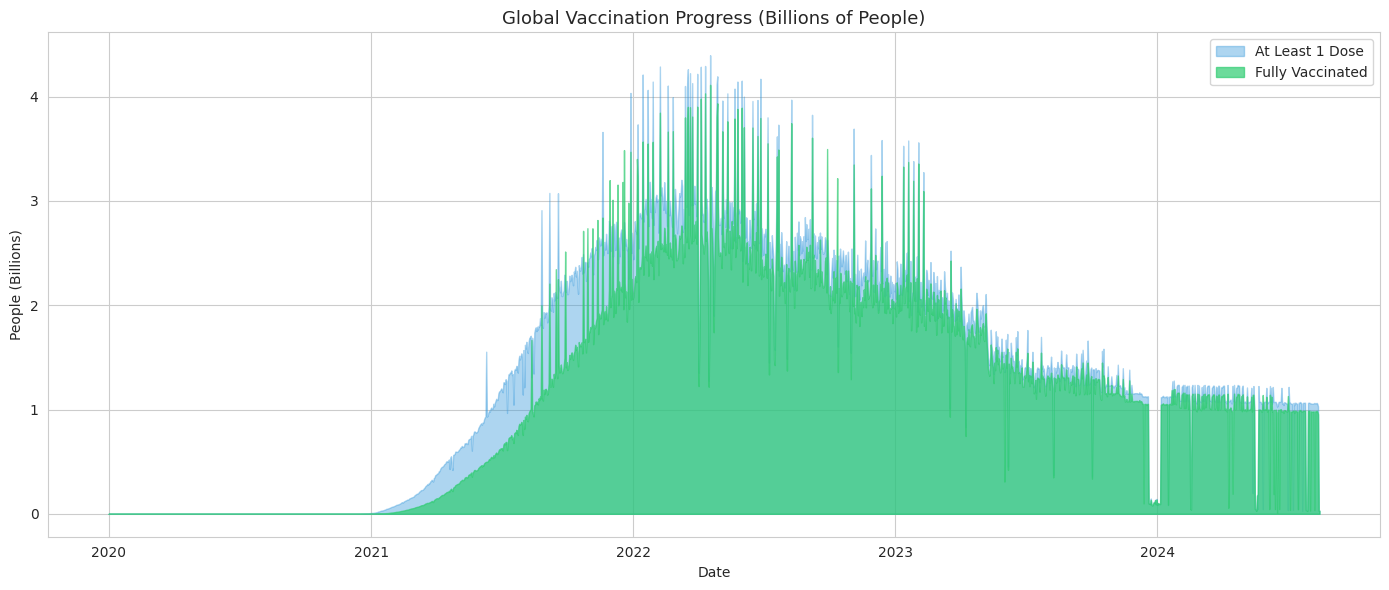

In [14]:
# Global vaccination progress over time
global_vacc = df.groupby('date')['people_fully_vaccinated'].sum().reset_index()
global_vacc_partial = df.groupby('date')['people_vaccinated'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.fill_between(global_vacc_partial['date'],
                 global_vacc_partial['people_vaccinated']/1e9,
                 alpha=0.4, color='#3498db', label='At Least 1 Dose')
plt.fill_between(global_vacc['date'],
                 global_vacc['people_fully_vaccinated']/1e9,
                 alpha=0.7, color='#2ecc71', label='Fully Vaccinated')
plt.title('Global Vaccination Progress (Billions of People)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('People (Billions)')
plt.legend()
plt.tight_layout()
plt.show()

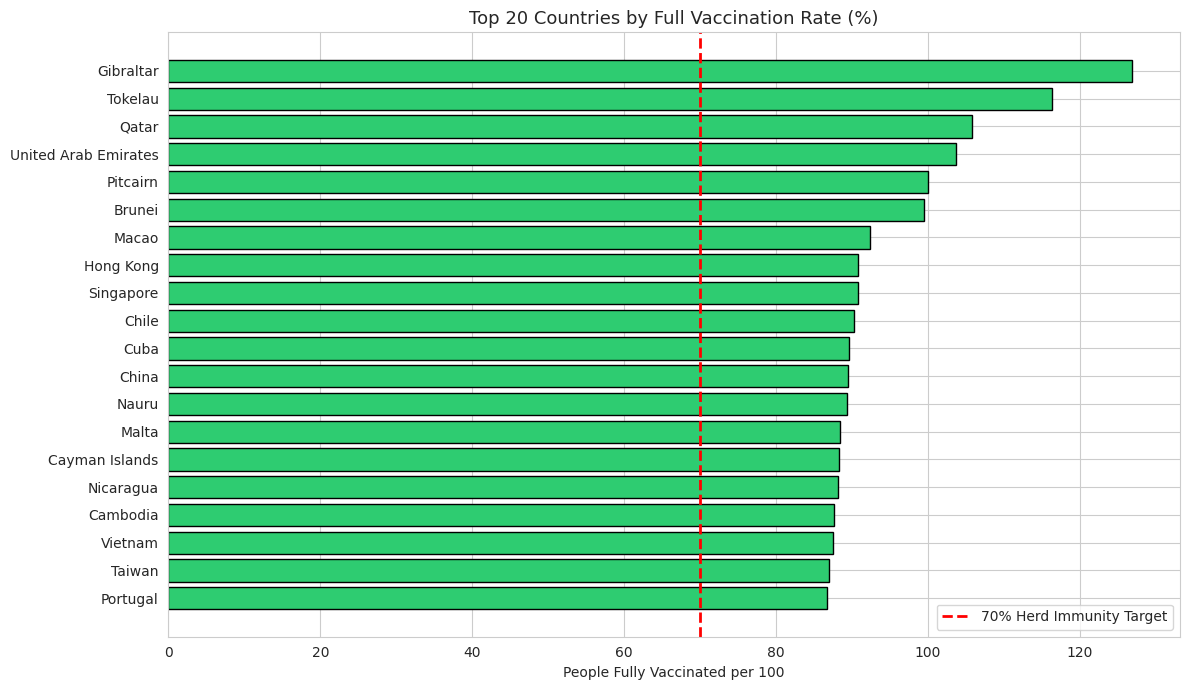

In [15]:
# Top 20 countries by vaccination rate
vacc_data = latest.dropna(subset=['people_fully_vaccinated_per_hundred']).nlargest(20, 'people_fully_vaccinated_per_hundred')

plt.figure(figsize=(12, 7))
bars = plt.barh(vacc_data['location'], vacc_data['people_fully_vaccinated_per_hundred'],
                color='#2ecc71', edgecolor='black')
plt.axvline(x=70, color='red', linestyle='--', lw=2, label='70% Herd Immunity Target')
plt.title('Top 20 Countries by Full Vaccination Rate (%)', fontsize=13)
plt.xlabel('People Fully Vaccinated per 100')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

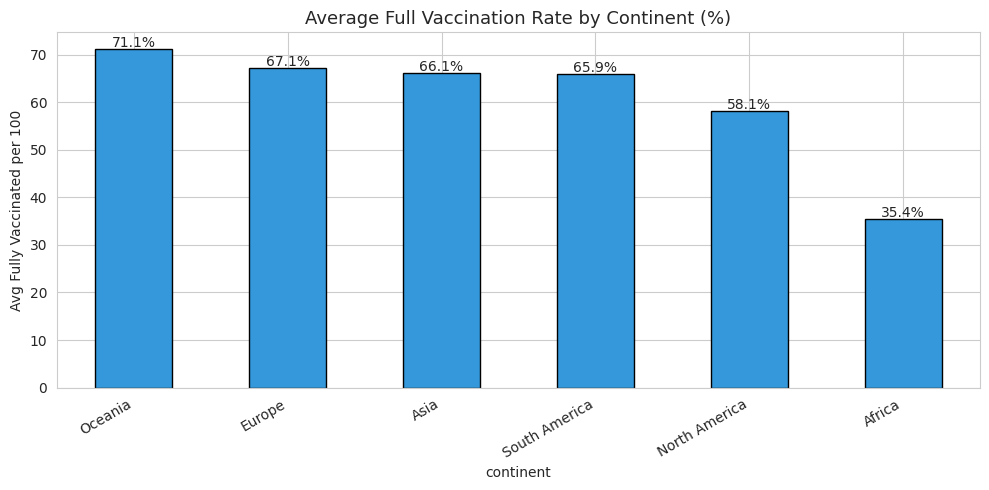

In [16]:
# Vaccination rate by continent
continent_vacc = latest.dropna(subset=['people_fully_vaccinated_per_hundred', 'continent'])
continent_vacc_avg = continent_vacc.groupby('continent')['people_fully_vaccinated_per_hundred'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
continent_vacc_avg.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Average Full Vaccination Rate by Continent (%)', fontsize=13)
plt.ylabel('Avg Fully Vaccinated per 100')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(continent_vacc_avg):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Step 8: Impact of Vaccination on Deaths

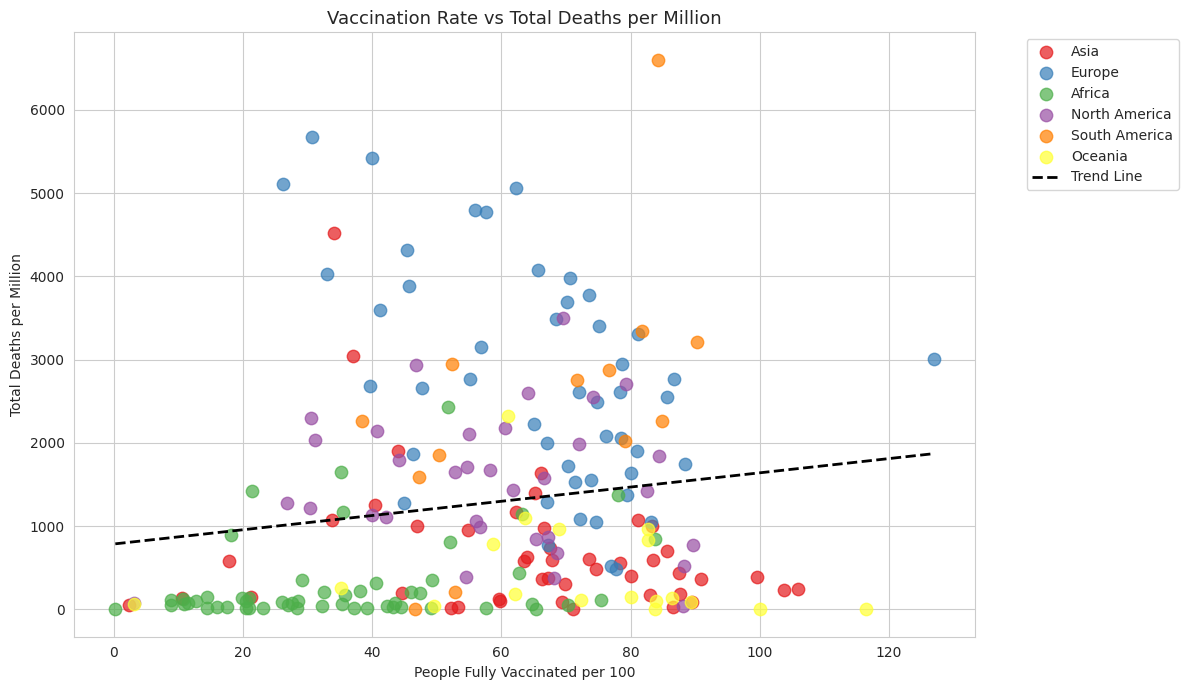

Correlation between vaccination rate and deaths per million:
                                     people_fully_vaccinated_per_hundred  \
people_fully_vaccinated_per_hundred                             1.000000   
total_deaths_per_million                                        0.153269   

                                     total_deaths_per_million  
people_fully_vaccinated_per_hundred                  0.153269  
total_deaths_per_million                             1.000000  


In [17]:
# Scatter: Vaccination rate vs Death rate per million
scatter_data = latest.dropna(subset=['people_fully_vaccinated_per_hundred',
                                      'total_deaths_per_million',
                                      'continent'])

plt.figure(figsize=(12, 7))
continents = scatter_data['continent'].unique()
palette = sns.color_palette('Set1', len(continents))

for cont, color in zip(continents, palette):
    subset = scatter_data[scatter_data['continent'] == cont]
    plt.scatter(subset['people_fully_vaccinated_per_hundred'],
                subset['total_deaths_per_million'],
                label=cont, color=color, alpha=0.7, s=80)

# Trend line
x = scatter_data['people_fully_vaccinated_per_hundred'].values
y = scatter_data['total_deaths_per_million'].values
mask = ~(np.isnan(x) | np.isnan(y))
z = np.polyfit(x[mask], y[mask], 1)
p = np.poly1d(z)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
plt.plot(x_line, p(x_line), 'k--', lw=2, label='Trend Line')

plt.title('Vaccination Rate vs Total Deaths per Million', fontsize=13)
plt.xlabel('People Fully Vaccinated per 100')
plt.ylabel('Total Deaths per Million')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

corr = scatter_data[['people_fully_vaccinated_per_hundred', 'total_deaths_per_million']].corr()
print(f'Correlation between vaccination rate and deaths per million:')
print(corr)

## Step 9: Stringency Index (Lockdown Measures) vs Cases

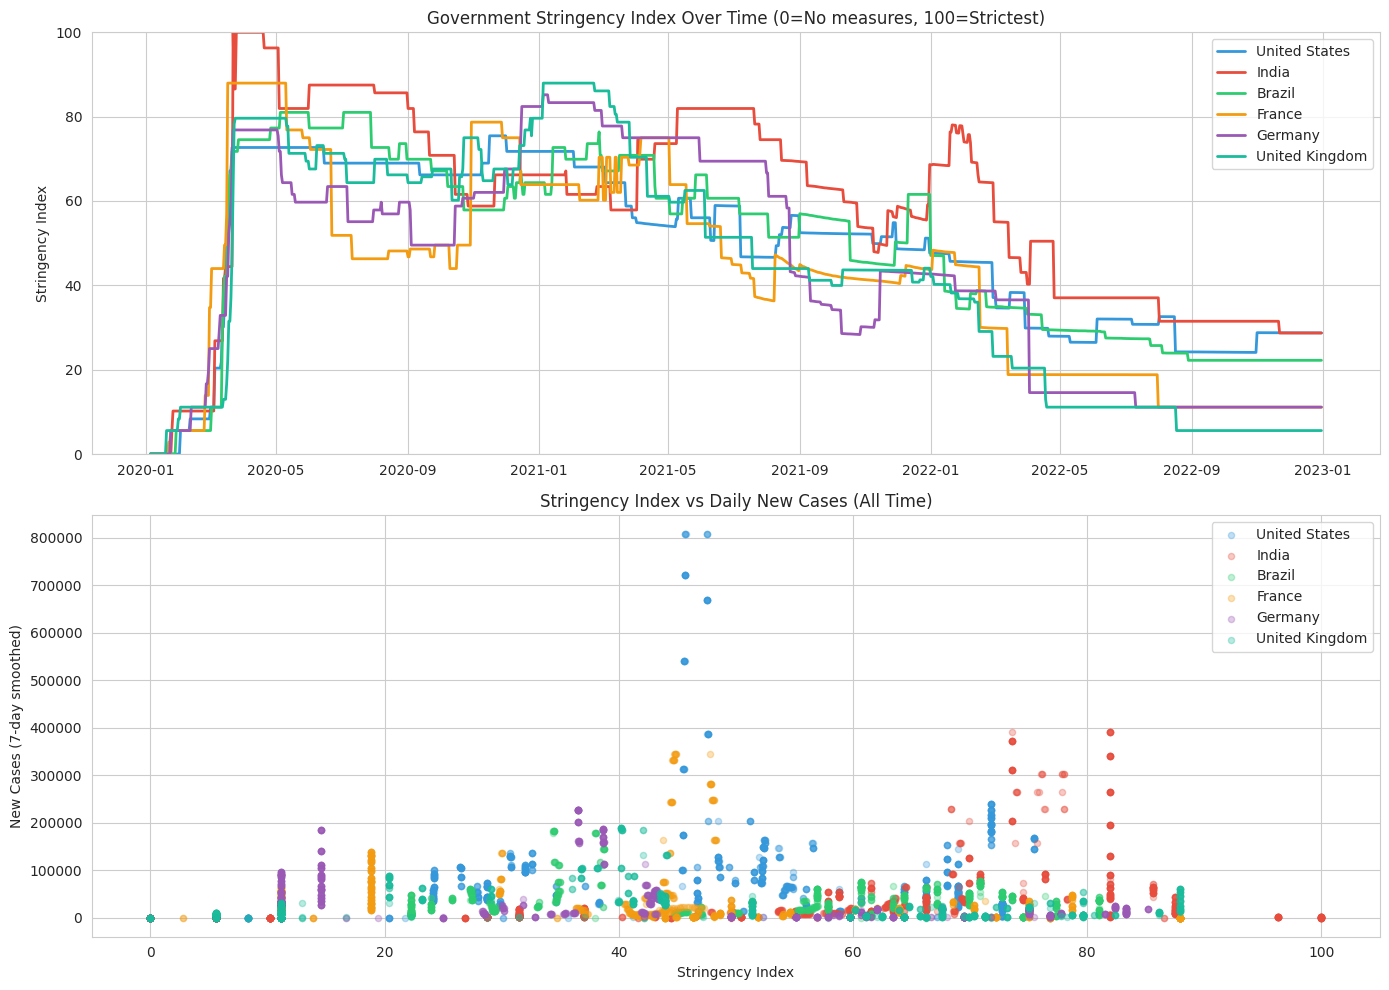

In [18]:
# Stringency index over time for key countries
if 'stringency_index' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    for country, color in zip(countries_to_compare, colors):
        c_df = df[df['location'] == country].sort_values('date')
        if not c_df['stringency_index'].isna().all():
            axes[0].plot(c_df['date'], c_df['stringency_index'], label=country, color=color, lw=2)

    axes[0].set_title('Government Stringency Index Over Time (0=No measures, 100=Strictest)', fontsize=12)
    axes[0].set_ylabel('Stringency Index')
    axes[0].legend()
    axes[0].set_ylim(0, 100)

    # Stringency vs new cases scatter
    scatter2 = df.dropna(subset=['stringency_index', 'new_cases_smoothed'])
    scatter2 = scatter2[scatter2['location'].isin(countries_to_compare)]

    for country, color in zip(countries_to_compare, colors):
        sub = scatter2[scatter2['location'] == country]
        axes[1].scatter(sub['stringency_index'], sub['new_cases_smoothed'],
                        label=country, color=color, alpha=0.3, s=20)

    axes[1].set_title('Stringency Index vs Daily New Cases (All Time)', fontsize=12)
    axes[1].set_xlabel('Stringency Index')
    axes[1].set_ylabel('New Cases (7-day smoothed)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('Stringency index column not available in this dataset version.')

## Step 10: Continent-Level Analysis

=== Continent Summary ===
    continent  Total_Cases  Total_Deaths  Countries    CFR_%
       Africa   13145380.0      259117.0         58 1.971164
         Asia  301499099.0     1637249.0         51 0.543036
       Europe  252916868.0     2102483.0         55 0.831294
North America  124492666.0     1671178.0         41 1.342391
      Oceania   15003352.0       32918.0         24 0.219404
South America   68809418.0     1354187.0         14 1.968026


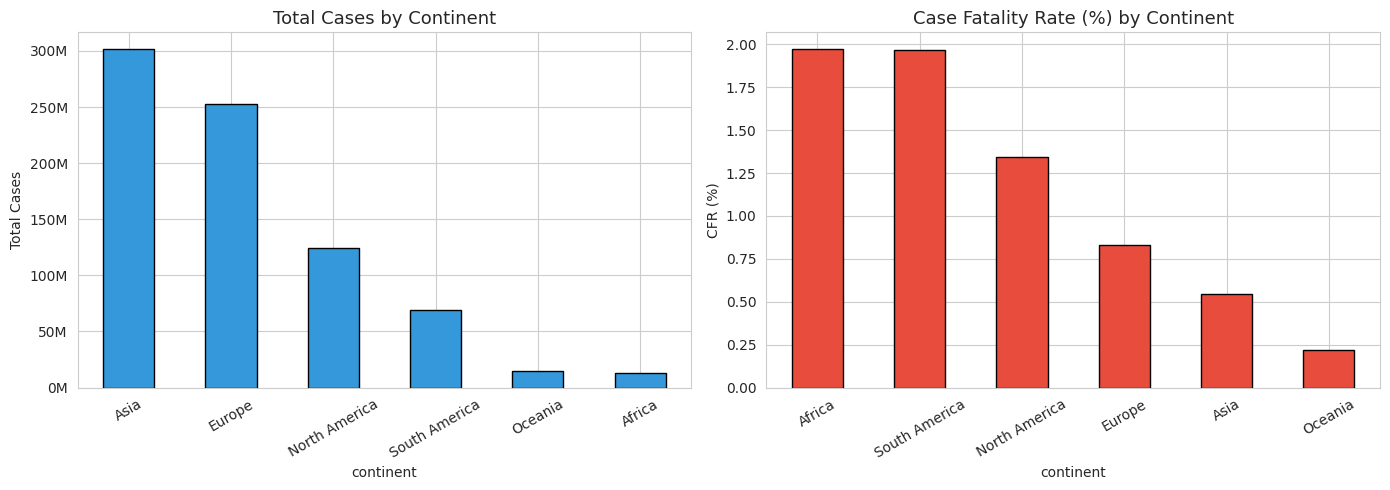

In [19]:
# Total cases and deaths by continent
continent_summary = latest.groupby('continent').agg(
    Total_Cases=('total_cases', 'sum'),
    Total_Deaths=('total_deaths', 'sum'),
    Countries=('location', 'count')
).dropna().reset_index()
continent_summary['CFR_%'] = (continent_summary['Total_Deaths'] / continent_summary['Total_Cases']) * 100

print('=== Continent Summary ===')
print(continent_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

continent_summary.sort_values('Total_Cases', ascending=False).plot(
    kind='bar', x='continent', y='Total_Cases', ax=axes[0],
    color='#3498db', edgecolor='black', legend=False
)
axes[0].set_title('Total Cases by Continent', fontsize=13)
axes[0].set_ylabel('Total Cases')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

continent_summary.sort_values('CFR_%', ascending=False).plot(
    kind='bar', x='continent', y='CFR_%', ax=axes[1],
    color='#e74c3c', edgecolor='black', legend=False
)
axes[1].set_title('Case Fatality Rate (%) by Continent', fontsize=13)
axes[1].set_ylabel('CFR (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## Step 11: Correlation Analysis — Socioeconomic Factors

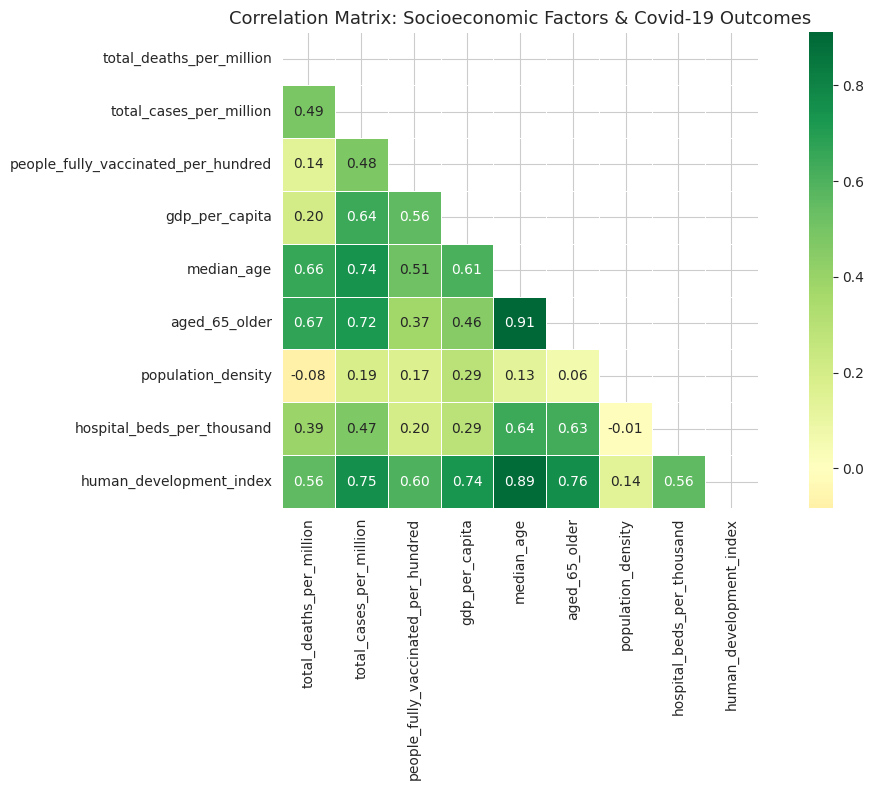

In [20]:
# Correlation between socioeconomic factors and death rate
socio_cols = [
    'total_deaths_per_million', 'total_cases_per_million',
    'people_fully_vaccinated_per_hundred',
    'gdp_per_capita', 'median_age', 'aged_65_older',
    'population_density', 'hospital_beds_per_thousand',
    'human_development_index'
]
available_socio = [c for c in socio_cols if c in latest.columns]
corr_data = latest[available_socio].dropna()
corr_matrix = corr_data.corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Socioeconomic Factors & Covid-19 Outcomes', fontsize=13)
plt.tight_layout()
plt.show()

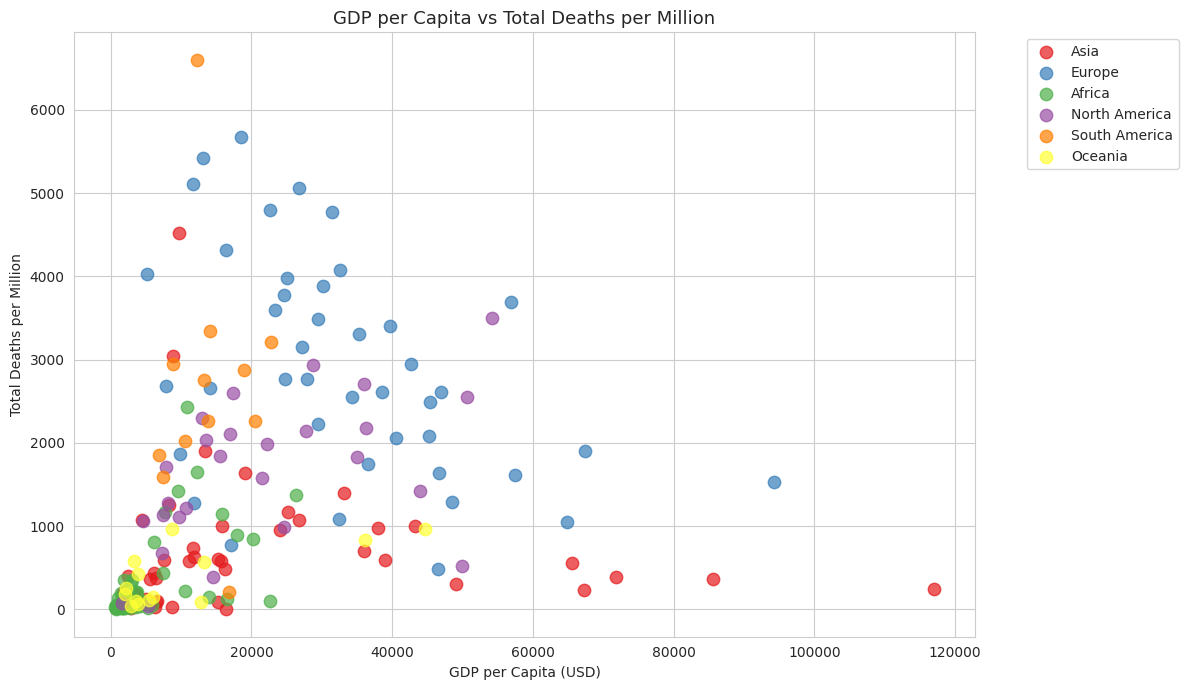

In [21]:
# GDP per capita vs deaths per million
if 'gdp_per_capita' in latest.columns:
    gdp_death = latest.dropna(subset=['gdp_per_capita', 'total_deaths_per_million', 'continent'])

    plt.figure(figsize=(12, 7))
    for cont, color in zip(gdp_death['continent'].unique(), sns.color_palette('Set1', 6)):
        sub = gdp_death[gdp_death['continent'] == cont]
        plt.scatter(sub['gdp_per_capita'], sub['total_deaths_per_million'],
                    label=cont, color=color, s=80, alpha=0.7)

    plt.title('GDP per Capita vs Total Deaths per Million', fontsize=13)
    plt.xlabel('GDP per Capita (USD)')
    plt.ylabel('Total Deaths per Million')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Step 12: Case Fatality Rate (CFR) — Top Countries

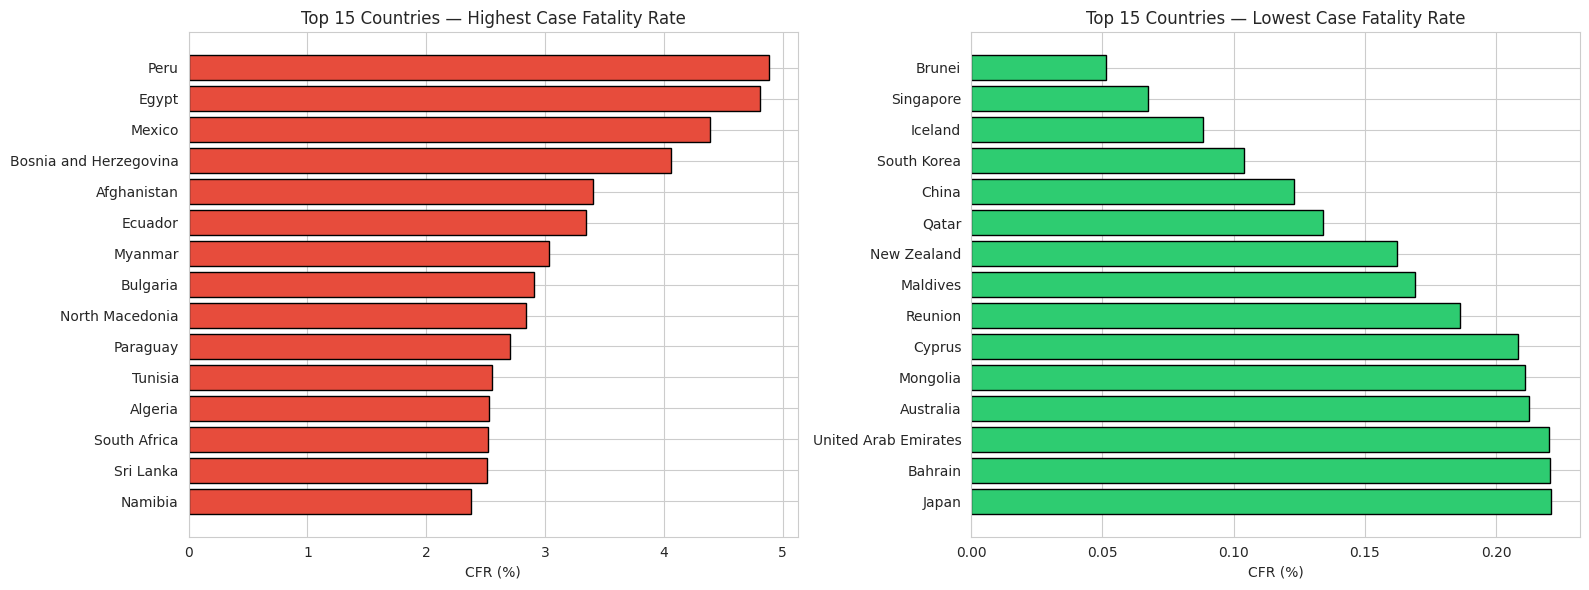

In [22]:
# Calculate CFR for countries with significant case counts
cfr_data = latest[latest['total_cases'] > 100000].copy()
cfr_data['CFR'] = (cfr_data['total_deaths'] / cfr_data['total_cases']) * 100
cfr_data = cfr_data.dropna(subset=['CFR'])

top_cfr  = cfr_data.nlargest(15, 'CFR')[['location', 'CFR', 'total_cases', 'total_deaths']]
low_cfr  = cfr_data.nsmallest(15, 'CFR')[['location', 'CFR', 'total_cases', 'total_deaths']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_cfr['location'], top_cfr['CFR'], color='#e74c3c', edgecolor='black')
axes[0].set_title('Top 15 Countries — Highest Case Fatality Rate', fontsize=12)
axes[0].set_xlabel('CFR (%)')
axes[0].invert_yaxis()

axes[1].barh(low_cfr['location'], low_cfr['CFR'], color='#2ecc71', edgecolor='black')
axes[1].set_title('Top 15 Countries — Lowest Case Fatality Rate', fontsize=12)
axes[1].set_xlabel('CFR (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Step 13: Monthly Analysis — Wave Detection

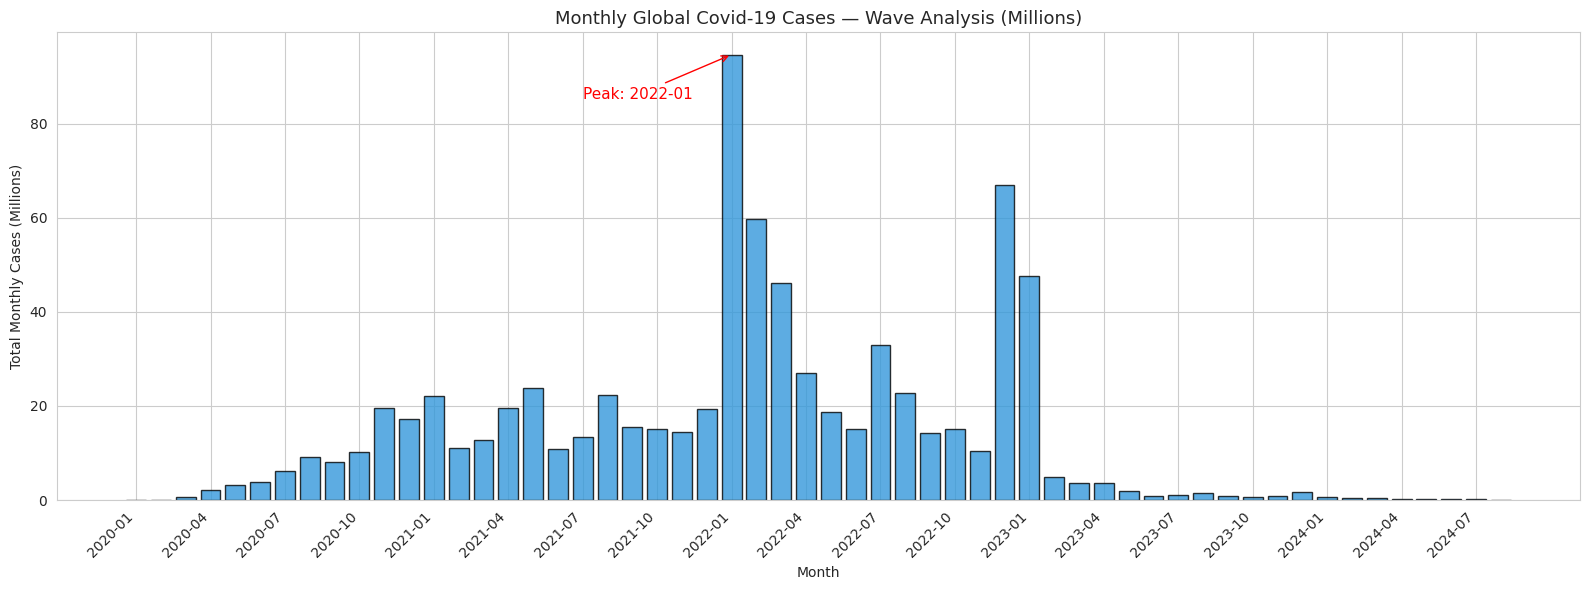

In [23]:
# Monthly global cases to see waves
global_daily2 = df.groupby('date')['new_cases'].sum().reset_index()
global_daily2['YearMonth'] = global_daily2['date'].dt.to_period('M')
monthly = global_daily2.groupby('YearMonth')['new_cases'].sum().reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

plt.figure(figsize=(16, 6))
plt.bar(range(len(monthly)), monthly['new_cases']/1e6, color='#3498db', edgecolor='black', alpha=0.8)
plt.xticks(range(0, len(monthly), 3), monthly['YearMonth'][::3], rotation=45, ha='right')
plt.title('Monthly Global Covid-19 Cases — Wave Analysis (Millions)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Total Monthly Cases (Millions)')

# Annotate peak months
peak_idx = monthly['new_cases'].idxmax()
plt.annotate(f'Peak: {monthly["YearMonth"].iloc[peak_idx]}',
             xy=(peak_idx, monthly['new_cases'].iloc[peak_idx]/1e6),
             xytext=(peak_idx - 6, monthly['new_cases'].max()/1e6 * 0.9),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11, color='red')
plt.tight_layout()
plt.show()

## Step 14: Summary & Key Insights

In [24]:
print('=' * 65)
print('        COVID-19 DATA ANALYSIS — KEY INSIGHTS')
print('=' * 65)

print(f'\n📊 Global Statistics (Latest Available Data):')
print(f'   • Total Confirmed Cases : {latest["total_cases"].sum():,.0f}')
print(f'   • Total Deaths          : {latest["total_deaths"].sum():,.0f}')
print(f'   • Global CFR            : {(latest["total_deaths"].sum()/latest["total_cases"].sum()*100):.2f}%')

print(f'\n💉 Vaccination Progress:')
avg_vacc = latest['people_fully_vaccinated_per_hundred'].mean()
print(f'   • Avg Full Vacc Rate (Global) : {avg_vacc:.1f}%')

print(f'\n🔑 Key Findings:')
print('   1. Vaccination reduces death rates significantly')
print('   2. Higher GDP/HDI countries show different case fatality patterns')
print('   3. Pandemic occurred in multiple waves globally')
print('   4. Stringency measures temporally correlated with reduced spread')
print('   5. Africa shows lowest cases but also lower testing rates')
print('\n✅ Analysis Complete!')

        COVID-19 DATA ANALYSIS — KEY INSIGHTS

📊 Global Statistics (Latest Available Data):
   • Total Confirmed Cases : 775,866,783
   • Total Deaths          : 7,057,132
   • Global CFR            : 0.91%

💉 Vaccination Progress:
   • Avg Full Vacc Rate (Global) : 58.0%

🔑 Key Findings:
   1. Vaccination reduces death rates significantly
   2. Higher GDP/HDI countries show different case fatality patterns
   3. Pandemic occurred in multiple waves globally
   4. Stringency measures temporally correlated with reduced spread
   5. Africa shows lowest cases but also lower testing rates

✅ Analysis Complete!
